In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset
df = pd.read_csv("1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv")

# Display first 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
# Number of rows and columns
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Dataset information
print("\nDataset Information:")
df.info()

Dataset Shape: (301, 9)

Columns:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [ ]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 2


In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (299, 9)


In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.567887,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
print("Fuel Type:")
print(df["Fuel_Type"].value_counts())

print("\nSeller Type:")
print(df["Seller_Type"].value_counts())

print("\nTransmission:")
print(df["Transmission"].value_counts())

print("\nOwner:")
print(df["Owner"].value_counts())

Fuel Type:
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Seller Type:
Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64

Transmission:
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

Owner:
Owner
0    288
1     10
3      1
Name: count, dtype: int64


In [ ]:
current_year = 2026

df["Car_Age"] = current_year - df["Year"]

df[["Year", "Car_Age"]].head()

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


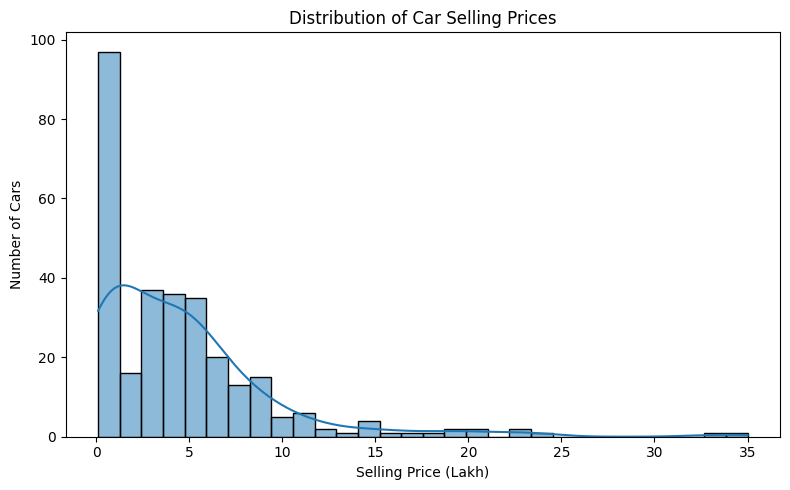

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Selling_Price"],
    bins=30,
    kde=True
)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price (Lakh)")
plt.ylabel("Number of Cars")

plt.tight_layout()
plt.show()

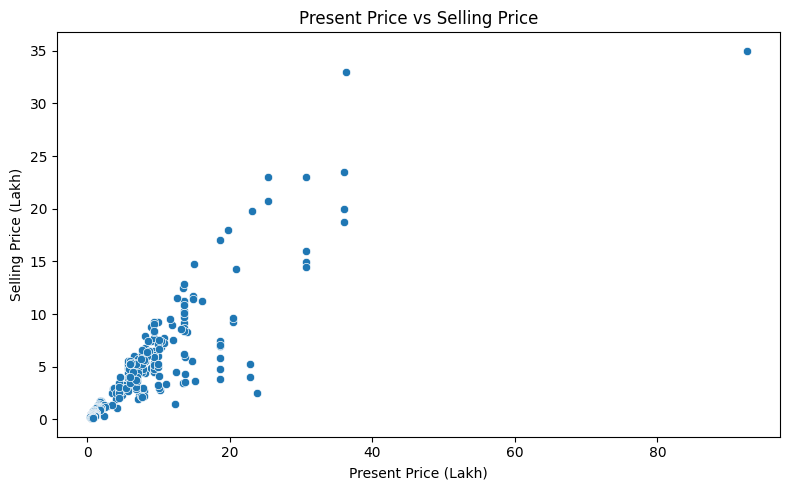

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price"
)

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price (Lakh)")
plt.ylabel("Selling Price (Lakh)")

plt.tight_layout()
plt.show()

In [ ]:
correlation = df["Present_Price"].corr(df["Selling_Price"])

print("Correlation between Present Price and Selling Price:",
      round(correlation, 3))

Correlation between Present Price and Selling Price: 0.876


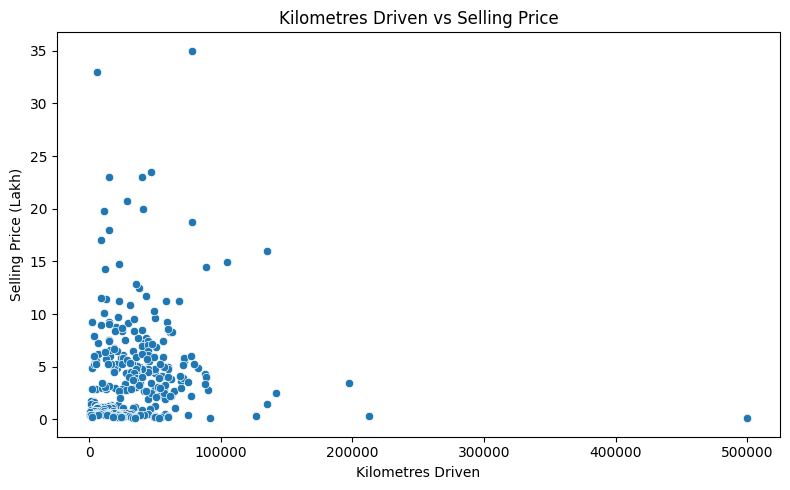

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Kms_Driven",
    y="Selling_Price"
)

plt.title("Kilometres Driven vs Selling Price")
plt.xlabel("Kilometres Driven")
plt.ylabel("Selling Price (Lakh)")

plt.tight_layout()
plt.show()

In [ ]:
correlation = df["Kms_Driven"].corr(df["Selling_Price"])

print("Correlation:",
      round(correlation, 3))

Correlation: 0.029


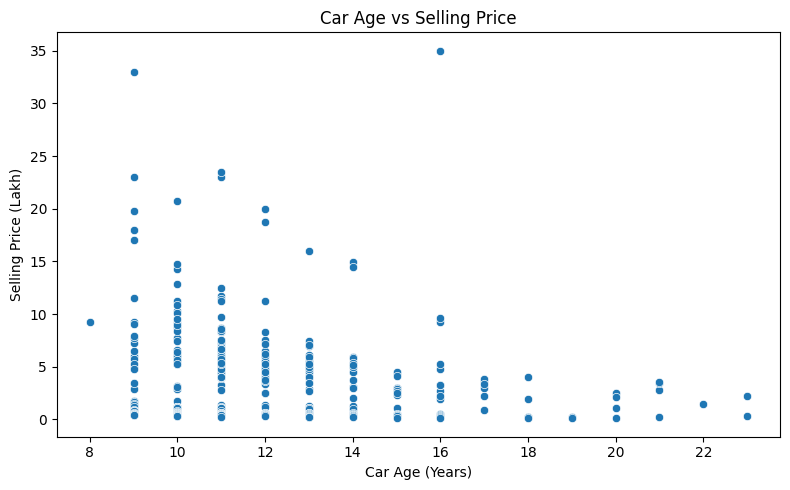

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Selling_Price"
)

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price (Lakh)")

plt.tight_layout()
plt.show()

In [ ]:
correlation = df["Car_Age"].corr(df["Selling_Price"])

print("Correlation:",
      round(correlation, 3))

Correlation: -0.234


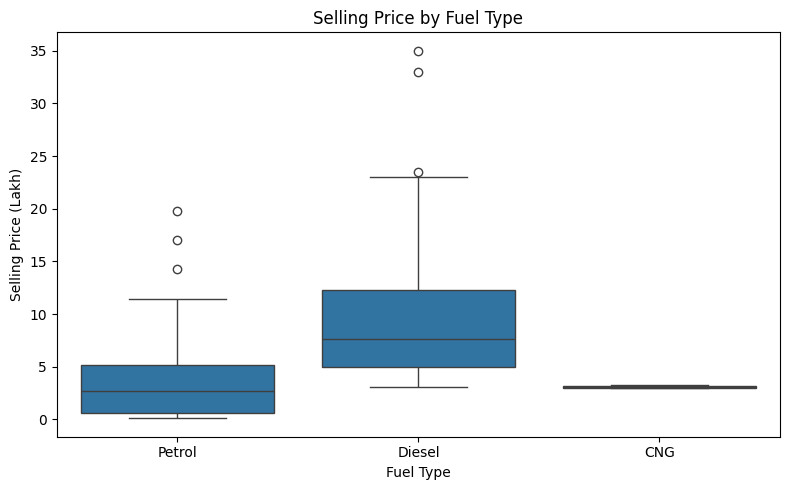

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Fuel_Type",
    y="Selling_Price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price (Lakh)")

plt.tight_layout()
plt.show()

In [ ]:
fuel_price = df.groupby("Fuel_Type")["Selling_Price"].mean()

print(fuel_price)

Fuel_Type
CNG        3.100000
Diesel    10.102759
Petrol     3.264184
Name: Selling_Price, dtype: float64


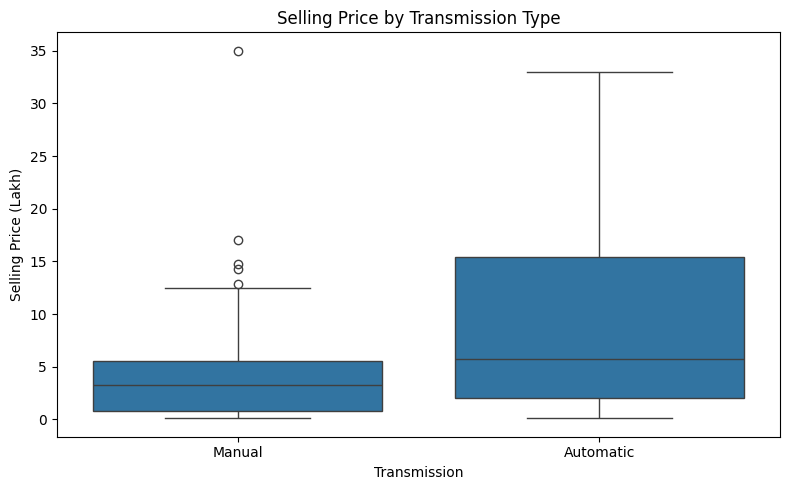

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Transmission",
    y="Selling_Price"
)

plt.title("Selling Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Selling Price (Lakh)")

plt.tight_layout()
plt.show()

In [ ]:
transmission_price = df.groupby("Transmission")["Selling_Price"].mean()

print(transmission_price)

Transmission
Automatic    9.071795
Manual       3.917308
Name: Selling_Price, dtype: float64


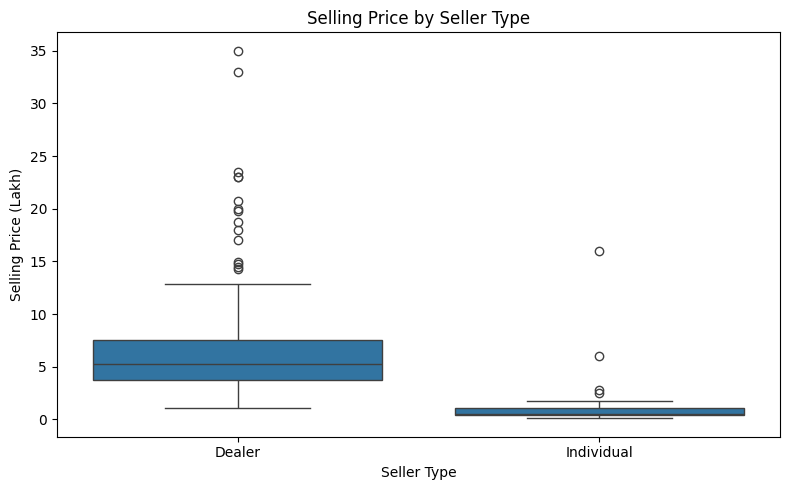

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Seller_Type",
    y="Selling_Price"
)

plt.title("Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Selling Price (Lakh)")

plt.tight_layout()
plt.show()

In [ ]:
seller_price = df.groupby("Seller_Type")["Selling_Price"].mean()

print(seller_price)

Seller_Type
Dealer        6.632021
Individual    0.870943
Name: Selling_Price, dtype: float64


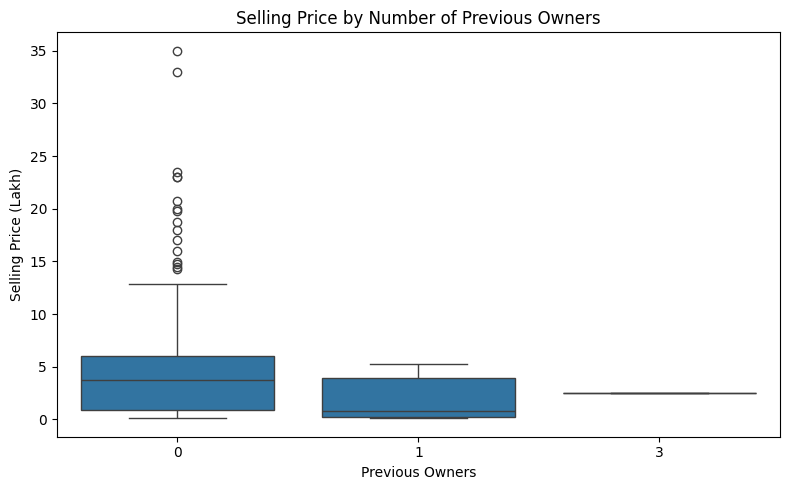

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Owner",
    y="Selling_Price"
)

plt.title("Selling Price by Number of Previous Owners")
plt.xlabel("Previous Owners")
plt.ylabel("Selling Price (Lakh)")

plt.tight_layout()
plt.show()

In [ ]:
correlation = df["Owner"].corr(df["Selling_Price"])

print("Correlation:",
      round(correlation, 3))

Correlation: -0.088


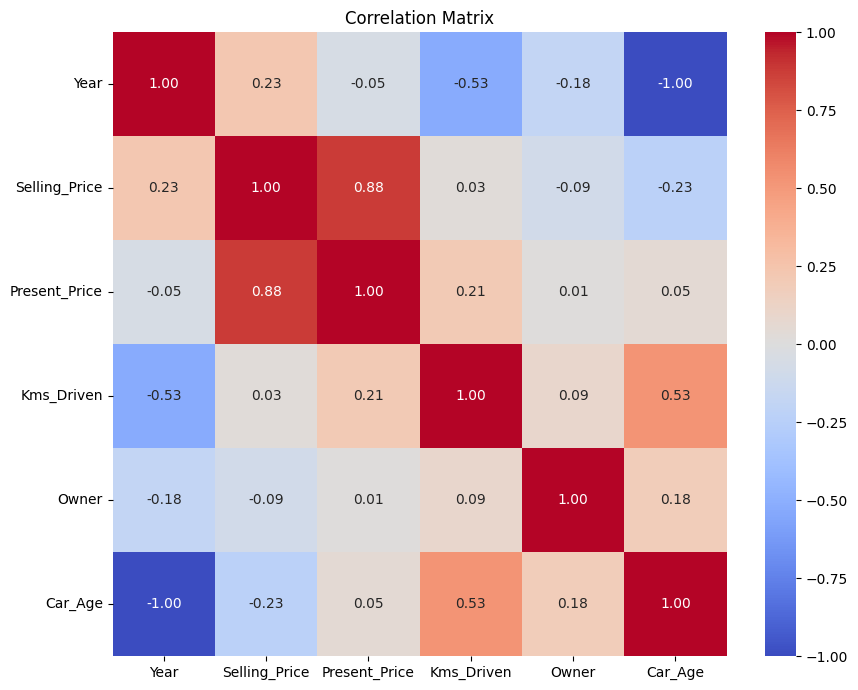

In [ ]:
plt.figure(figsize=(9, 7))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [ ]:
top_cars = df.sort_values(
    "Selling_Price",
    ascending=False
).head(10)

top_cars[
    ["Car_Name", "Year", "Selling_Price",
     "Present_Price", "Kms_Driven"]
]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven
86,land cruiser,2010,35.00,92.60,78000
64,fortuner,2017,33.00,36.23,6000
63,fortuner,2015,23.50,35.96,47000
82,innova,2017,23.00,25.39,15000
51,fortuner,2015,23.00,30.61,40000
96,innova,2016,20.75,25.39,29000
59,fortuner,2014,19.99,35.96,41000
66,innova,2017,19.75,23.15,11000
62,fortuner,2014,18.75,35.96,78000
52,innova,2017,18.00,19.77,15000


In [ ]:
print("----- CAR MARKET ANALYSIS SUMMARY -----")

print("Total Records:", len(df))

print("Average Selling Price:",
      round(df["Selling_Price"].mean(), 2), "Lakh")

print("Average Present Price:",
      round(df["Present_Price"].mean(), 2), "Lakh")

print("Average Kilometres Driven:",
      round(df["Kms_Driven"].mean(), 0), "km")

print("Present Price-Selling Price Correlation:",
      round(df["Present_Price"].corr(df["Selling_Price"]), 3))

print("Car Age-Selling Price Correlation:",
      round(df["Car_Age"].corr(df["Selling_Price"]), 3))

print("Kms Driven-Selling Price Correlation:",
      round(df["Kms_Driven"].corr(df["Selling_Price"]), 3))

----- CAR MARKET ANALYSIS SUMMARY -----
Total Records: 299
Average Selling Price: 4.59 Lakh
Average Present Price: 7.54 Lakh
Average Kilometres Driven: 36917.0 km
Present Price-Selling Price Correlation: 0.876
Car Age-Selling Price Correlation: -0.234
Kms Driven-Selling Price Correlation: 0.029
